<h1><center>PENERAPAN OLAP</center>
</h1>

<h3>
NAMA: RAFAEL HARTONO    

NIM: 24031554166

KELAS: 2024C

MATA KULIAH: DATA WAREHOUSE
</h3>



Github Link: https://github.com/rafaelhartono8/Multi-Asset-Analysis-1927-to-Now.git

In [ ]:
import yfinance as yf
import atoti as tt
import pandas as pd
from datetime import datetime

tickers = [
    'GC=F', 'SI=F', 'CL=F', 'NG=F', 'HG=F', 
    'BTC-USD',                              
    'NVDA', 'AAPL', 'MSFT', 'TSLA', 'GOOGL',
    'BBCA.JK', 'BBRI.JK', 'TLKM.JK', 'ASII.JK', 
    '^GSPC', '^JKSE', '^IXIC', 'IDR=X', '^TNX'  
]

print("Mengumpulkan data dari Yahoo Finance")


data = yf.download(tickers, start="1927-01-01")['Close']

df = data.stack().reset_index()
df.columns = ['Date', 'Symbol', 'Price']
df['Date'] = pd.to_datetime(df['Date'])

df.to_feather('20_market_data.feather')

print(f"Berhasil menarik {len(df)} baris data")
df

Welcome to Atoti 0.9.13!

By using this community edition, you agree with the license available at https://docs.activeviam.com/products/atoti/python-sdk/latest/eula.html.
Browse the official documentation at https://docs.activeviam.com/products/atoti/python-sdk.
Join the community at https://www.atoti.io/register.

Atoti collects telemetry data, which is used to help understand how to improve the product.
If you don't wish to send usage data, you can request a trial license at https://www.atoti.io/evaluation-license-request.

You can hide this message by setting the `ATOTI_HIDE_EULA_MESSAGE` environment variable to True.


In [2]:
df = pd.read_feather('20_market_data.feather')
print(f"Berhasil menarik {len(df)} baris data")
df

Berhasil menarik 166061 baris data


,Date,Symbol,Price
0,1927-12-30,^GSPC,17.660000
1,1928-01-03,^GSPC,17.760000
2,1928-01-04,^GSPC,17.719999
3,1928-01-05,^GSPC,17.549999
4,1928-01-06,^GSPC,17.660000
...,...,...,...
166056,2026-03-16,IDR=X,16990.000000
166057,2026-03-16,NG=F,3.122000
166058,2026-03-16,SI=F,80.364998
166059,2026-03-16,TLKM.JK,2910.000000


In [3]:
asset_mapping = {
    'GC=F': 'Komoditas', 'SI=F': 'Komoditas', 'CL=F': 'Komoditas', 'NG=F': 'Komoditas', 'HG=F': 'Komoditas',
    'BTC-USD': 'Kripto',
    'NVDA': 'Saham Teknologi', 'AAPL': 'Saham Teknologi', 'MSFT': 'Saham Teknologi', 'TSLA': 'Saham Teknologi', 'GOOGL': 'Saham Teknologi',
    'BBCA.JK': 'Saham Indonesia', 'BBRI.JK': 'Saham Indonesia', 'TLKM.JK': 'Saham Indonesia', 'ASII.JK': 'Saham Indonesia',
    '^GSPC': 'Indeks & Mata Uang', '^JKSE': 'Indeks & Mata Uang', '^IXIC': 'Indeks & Mata Uang', 'IDR=X': 'Indeks & Mata Uang', '^TNX': 'Indeks & Mata Uang'
}

df['Kategori'] = df['Symbol'].map(asset_mapping)

df

,Date,Symbol,Price,Kategori
0,1927-12-30,^GSPC,17.660000,Indeks & Mata Uang
1,1928-01-03,^GSPC,17.760000,Indeks & Mata Uang
2,1928-01-04,^GSPC,17.719999,Indeks & Mata Uang
3,1928-01-05,^GSPC,17.549999,Indeks & Mata Uang
4,1928-01-06,^GSPC,17.660000,Indeks & Mata Uang
...,...,...,...,...
166056,2026-03-16,IDR=X,16990.000000,Indeks & Mata Uang
166057,2026-03-16,NG=F,3.122000,Komoditas
166058,2026-03-16,SI=F,80.364998,Komoditas
166059,2026-03-16,TLKM.JK,2910.000000,Saham Indonesia


In [ ]:


session = tt.Session.start()
macro_table = session.read_pandas(df, table_name="MarketData", keys=["Date", "Symbol"])



In [5]:
macro_table.head()

,,Price,Kategori
Date,Symbol,,
1927-12-30,^GSPC,17.66,Indeks & Mata Uang
1928-01-11,^GSPC,17.35,Indeks & Mata Uang
1928-02-06,^GSPC,17.450001,Indeks & Mata Uang
1928-02-07,^GSPC,17.440001,Indeks & Mata Uang
1928-02-27,^GSPC,17.110001,Indeks & Mata Uang


In [ ]:
cube = session.create_cube(macro_table)
h = cube.hierarchies
l = cube.levels
m = cube.measures



cube.create_date_hierarchy(
    "Periode Analisis", 
    column=macro_table["Date"],
    levels={
        "Tahun": "yyyy",
        "Bulan": "MMMM",
        "Hari": "dd"
    }
)


del h["Date"]


print('Hierarchies:', list(h.keys()))
print('Levels:', list(l.keys()))
print('Measures:', list(m.keys()))

Hierarchies: [('MarketData', 'Kategori'), ('MarketData', 'Symbol'), ('MarketData', 'Periode Analisis')]
Levels: [('MarketData', 'Kategori', 'Kategori'), ('MarketData', 'Symbol', 'Symbol'), ('MarketData', 'Periode Analisis', 'Tahun'), ('MarketData', 'Periode Analisis', 'Bulan'), ('MarketData', 'Periode Analisis', 'Hari')]
Measures: ['Price.MEAN', 'Price.SUM', 'contributors.COUNT', 'update.TIMESTAMP']


HARGA ASLI

In [7]:
m["Price.VALUE"] = tt.agg.single_value(macro_table["Price"])


cube.query(
            m['Price.VALUE'], 
            levels=[l['Symbol'], l['Hari']])

Price.VALUE
Symbol Tahun Bulan    Hari            
AAPL   1980  December 12           .10
                      15           .09
                      16           .09
                      17           .09
                      18           .09
...                                ...
^TNX   2026  March    09          4.14
                      10          4.14
                      11          4.21
                      12          4.27
                      13          4.28

[166061 rows x 1 columns]

In [8]:
m["Price H-1"] = tt.shift(
                        m["Price.VALUE"], 
                        h["Periode Analisis"],
                        offset=-1,
                        mode="measure")

cube.query(
            m['Price.VALUE'], 
            m['Price H-1'], 
            levels=[l['Symbol'], l['Hari']])

Price.VALUE Price H-1
Symbol Tahun Bulan    Hari                      
AAPL   1980  December 12           .10          
                      15           .09       .10
                      16           .09       .09
                      17           .09       .09
                      18           .09       .09
...                                ...       ...
^TNX   2026  March    09          4.14      4.13
                      10          4.14      4.14
                      11          4.21      4.14
                      12          4.27      4.21
                      13          4.28      4.27

[166061 rows x 2 columns]

1. Berapa pergerakan harian dalam persentase?

In [9]:
m["Daily Return"] = ((m["Price.VALUE"] - m["Price H-1"]) / m["Price H-1"])
m["Daily Return"].formatter = "DOUBLE[0.00%]"
cube.query(m['Daily Return'], levels=[l['Symbol'], l['Hari']])

Daily Return
Symbol Tahun Bulan    Hari             
AAPL   1980  December 15         -5.22%
                      16         -7.34%
                      17          2.48%
                      18          2.90%
                      19          6.10%
...                                 ...
^TNX   2026  March    09          0.07%
                      10          0.00%
                      11          1.74%
                      12          1.54%
                      13          0.28%

[166041 rows x 1 columns]

![DAILY RETURN.png](<attachment:DAILY RETURN.png>)
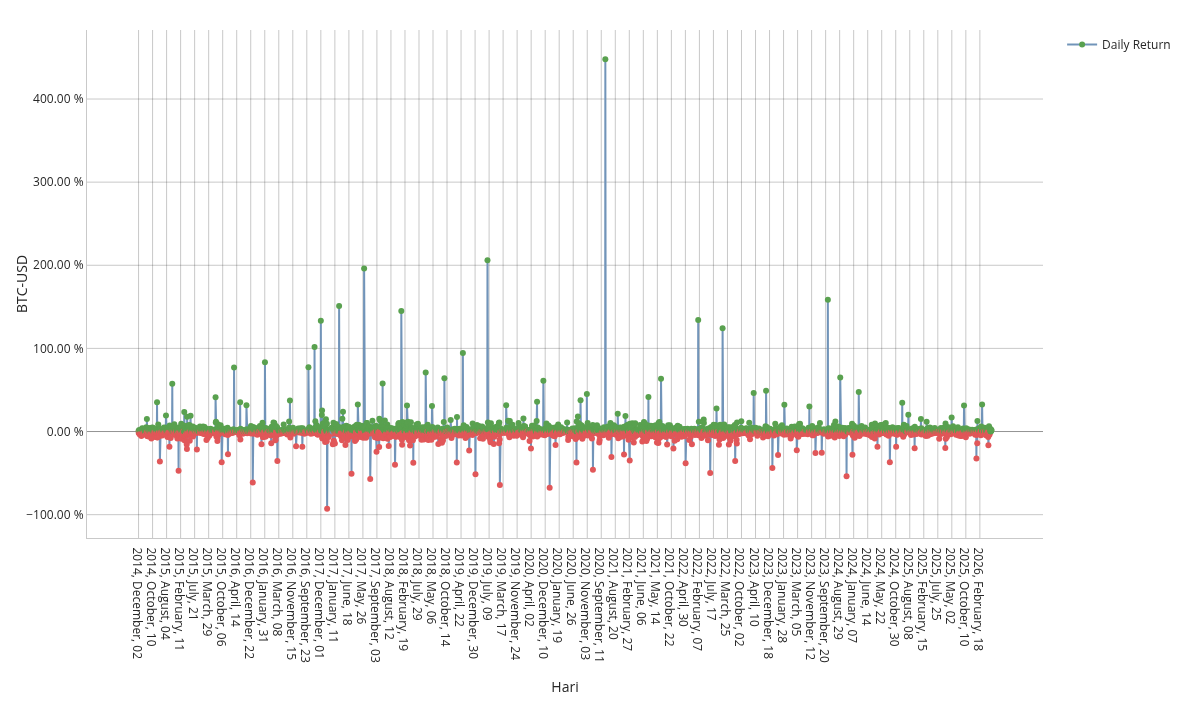

Pada perhitungan ini menunjukan pergerakan harga bitcoin harian dalam persentase, Perubahan harga bitcoin paling ekstrim ada pada 1 April 2021

2. Berapa keuntungan secara kumulatif sejak pertama kali rilis?

In [ ]:
cumulative_scope = tt.CumulativeScope(
                                    level=l["Hari"],
                                    )


m["Cumulative Return"] = tt.agg.prod(
    1 + m["Daily Return"], 
    scope=cumulative_scope
) - 1

m["Cumulative Return"].formatter = "DOUBLE[0.00%]"

cube.query(
            m["Cumulative Return"], 
            levels=[l["Symbol"], l["Hari"]],
            )

Cumulative Return
Symbol Tahun Bulan    Hari                  
AAPL   1980  December 12               0.00%
                      15              -5.22%
                      16             -12.17%
                      17             -10.00%
                      18              -7.39%
...                                      ...
^TNX   2026  March    09               7.15%
                      10               7.15%
                      11               9.02%
                      12              10.70%
                      13              11.01%

[166061 rows x 1 columns]

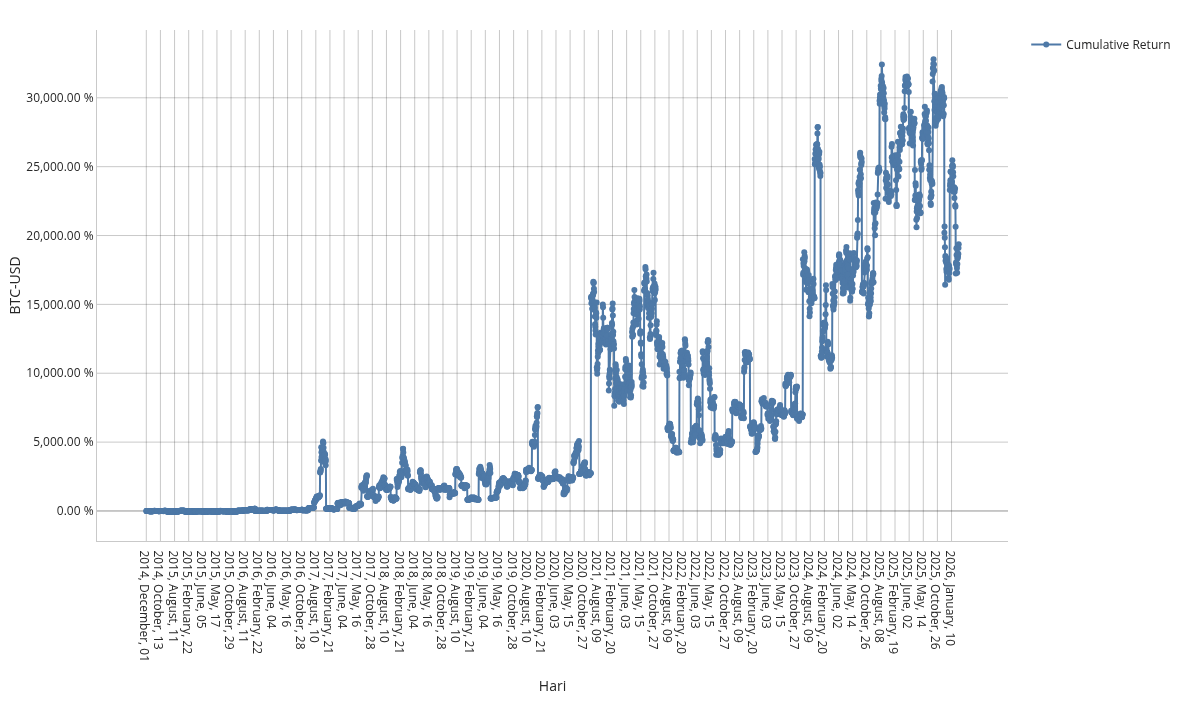

Pada visualisasi ini menunjukan bahwa bitcoin sudah mengalami ATH pada oktober 2025 dengan nilai sekitar 300kali lipat dari pertama kali rilis, dan di Febuari 2026 nilainya sedang turun menjadi sekitar 170 kali sejak pertama kali rilis

3. BERAPA MOVING AVERAGE 20 HARI TERAKHIR DARI TIAP INSTRUMEN?

In [11]:

m['SMA_20'] = tt.agg.mean(
    m["Price.VALUE"], 
    scope=tt.CumulativeScope(
        level=l["Hari"], 
        window=range(-19, 1) 
    )
)

m['SMA_20'].formatter = "DOUBLE[0.00]"

cube.query(
        m['SMA_20'], 
        m['Price.VALUE'],           
        levels=[l['Symbol'], l['Hari']])

SMA_20 Price.VALUE
Symbol Tahun Bulan    Hari                   
AAPL   1980  December 12     0.10         .10
                      15     0.09         .09
                      16     0.09         .09
                      17     0.09         .09
                      18     0.09         .09
...                           ...         ...
^TNX   2026  March    09     4.18        4.14
                      10     4.18        4.14
                      11     4.19        4.21
                      12     4.19        4.27
                      13     4.20        4.28

[166061 rows x 2 columns]

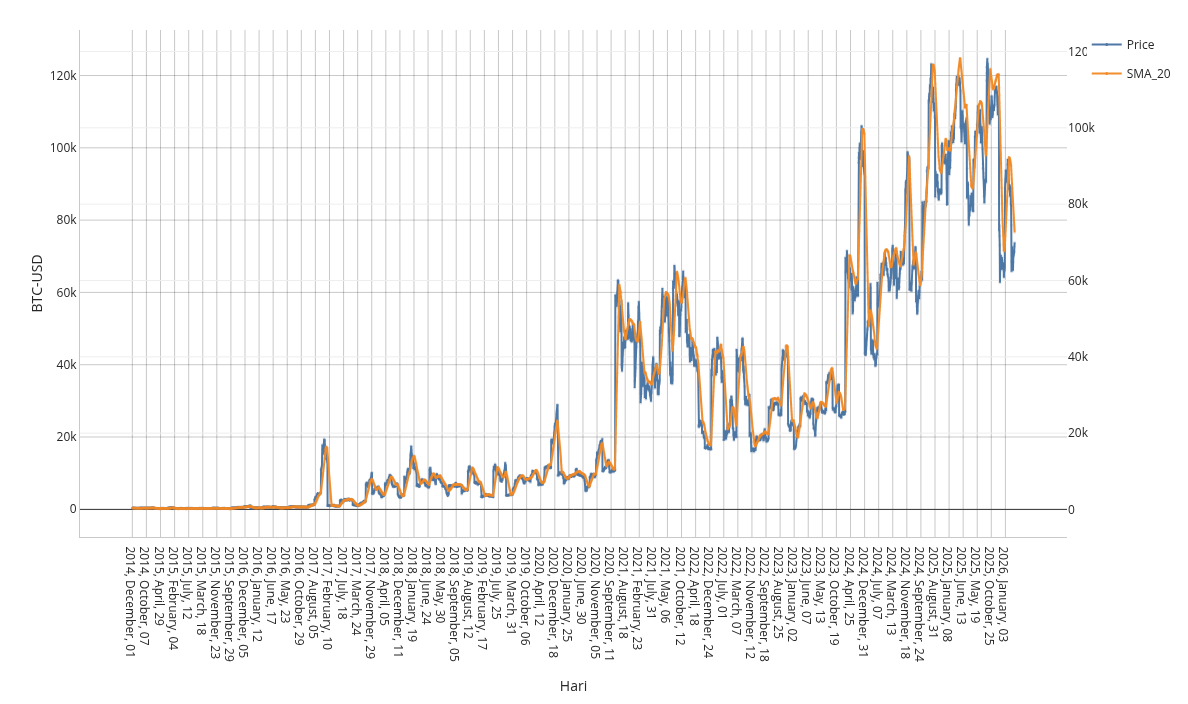

Harga Close Pasar banyak berisi dengan noise, oleh karena itu dibutuhkan filter untuk menghaluskan noisenya. Salah satunya dengan Simple Moving Average. Pada kasus ini saya pakai window 20 hari. Bisa dilihat cukup untuk menghaluskan sedikit noise, Apabila ingin lebih halus bisa menaikan ukuran window 

4. BERAPA VOLATILITAS 20 HARI TERAKHIR DARI TIAP INSTRUMEN?

In [ ]:

m["Volatility_20"] = tt.agg.std(
    m["Daily Return"],
    scope=tt.CumulativeScope(
        level=l["Hari"], 
        window=range(-19, 1)
    ) 
)

m["Volatility_20"].formatter = "DOUBLE[0.00%]"
cube.query(
        m["Volatility_20"], 
        levels=[l["Symbol"], l["Hari"]])

Volatility_20
Symbol Tahun Bulan    Hari              
AAPL   1980  December 15           1.50%
                      16           5.16%
                      17           5.25%
                      18           5.76%
                      19           5.55%
...                                  ...
^TNX   2026  March    09           1.27%
                      10           1.33%
                      11           1.36%
                      12           1.35%
                      13           1.38%

[166041 rows x 1 columns]

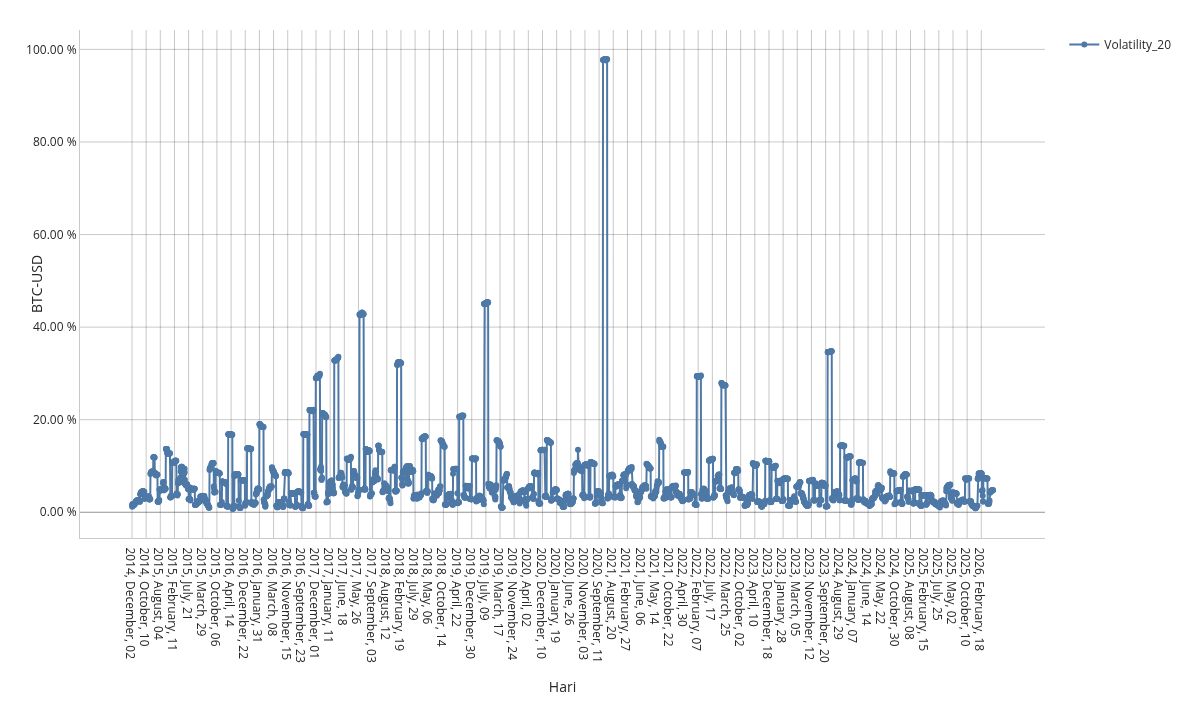

Menunjukan ketidak stabilan  bitcoin berada pada puncaknya di 2020 hingga 2021 

5. BERAPA RATA-RATA BULANAN DARI TIAP INSTRUMEN?

In [13]:
cube.query(m['Price.MEAN'], levels=[l['Symbol'], l['Bulan']])

Price.MEAN
Symbol Tahun Bulan               
AAPL   1980  December         .10
       1981  April            .09
             August           .08
             December         .07
             February         .09
...                           ...
^TNX   2025  October         4.05
             September       4.11
       2026  February        4.12
             January         4.21
             March           4.15

[7914 rows x 1 columns]

Data ini bisa membantu menjadikan acuan untuk menentukan mahal / murahnya harga pasar dalam bulanan

6. BERAPA RATA-RATA TAHUNAN DARI TIAP INSTRUMEN

In [14]:

cube.query(m['Price.MEAN'], levels=[l['Symbol'], l['Tahun']])

Price.MEAN
Symbol Tahun           
AAPL   1980         .10
       1981         .08
       1982         .07
       1983         .13
       1984         .09
...                 ...
^TNX   2022        2.96
       2023        3.97
       2024        4.21
       2025        4.29
       2026        4.16

[685 rows x 1 columns]

Data ini bisa membantu menjadikan acuan untuk menentukan mahal / murahnya harga pasar dalam tahunan

7. Berapa tahun waktu yang dibutuhkan S&P 500 untuk pulih ke titik nol setelah hancur di tahun 1929?

In [ ]:

m["Price"] = tt.agg.mean(macro_table["Price"])


m["Safe Price"] = tt.where(m["Price"] > 0, m["Price"], None)


m["Safe Rolling Max"] = tt.agg.max(
    m["Safe Price"], 
    scope=cumulative_scope
)


m["Safe Drawdown"] = tt.where(
    ~m["Safe Price"].isnull(),           
    (m["Safe Price"] / m["Safe Rolling Max"]) - 1,
    None
)

m["Safe Drawdown"].formatter = "DOUBLE[0.00%]"

In [ ]:



m["Is Breakeven"] = tt.where(m["Safe Drawdown"] >= 0.00, "SUDAH PULIH", "BELUM PULIH")


query_1927 = cube.query(
    m["Cumulative Return"],
    m["Safe Drawdown"],
    m["Is Breakeven"],
    levels=[l["Symbol"], l["Hari"]],
    filter=(
        (l["Symbol"].isin("^GSPC")) & 
        (l["Tahun"] >= "1927") & 
        (l["Tahun"] <= "1955")
    )
)

print("Analisis Krisis 1927:")
print(query_1927)

Analisis Krisis 1927:
                            Cumulative Return Safe Drawdown Is Breakeven
Symbol Tahun Bulan     Hari                                             
^GSPC  1927  December  30               0.00%         0.00%  SUDAH PULIH
       1928  April     02               7.08%         0.00%  SUDAH PULIH
                       03               7.70%         0.00%  SUDAH PULIH
                       04               7.53%        -0.16%  BELUM PULIH
                       05               8.89%         0.00%  SUDAH PULIH
...                                       ...           ...          ...
       1955  September 26             141.28%        -8.19%  BELUM PULIH
                       27             146.77%        -6.10%  BELUM PULIH
                       28             150.91%        -4.52%  BELUM PULIH
                       29             149.32%        -5.13%  BELUM PULIH
                       30             147.28%        -5.90%  BELUM PULIH

[6999 rows x 3 columns]


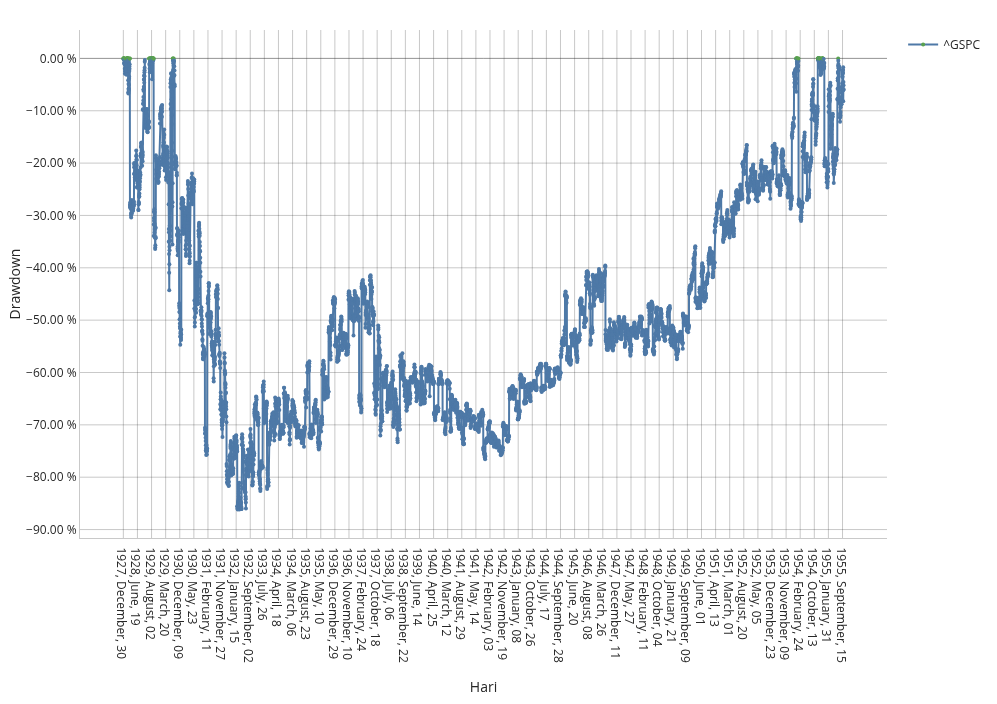

Grafik Drawdown digunakan untuk menunjukan seberapa besar krisis yang terjadi di periode tersebut. Pada kasus ini S&P500 dengan simbol ^GSPC mengalami penurunan sekitar 85% sejak pertama kali rilis dan baru pulih sekitar 25 tahun kemudian

In [18]:
bca_first = df[df['Symbol'] == 'BBCA.JK'].iloc[0]
print("\nData pertama untuk BBCA.JK:")
print(bca_first)


Data pertama untuk BBCA.JK:
Date        2004-06-08 00:00:00
Symbol                  BBCA.JK
Price                 99.041359
Kategori        Saham Indonesia
Name: 59941, dtype: object


8. Bagaimana daya tahan saham Indonesia (BBCA) dibandingkan pasar global (S&P 500) saat krisis Subprime Mortgage 2008??

In [19]:
query_2005 = cube.query(
    m["Cumulative Return"],
    m["Safe Drawdown"],
    m["Is Breakeven"],
    levels=[l["Symbol"], l["Hari"]],
    filter=(
        (l["Symbol"].isin("BBCA.JK", "^GSPC")) & 
        (l["Tahun"] >= "2005") & 
        (l["Tahun"] <= "2010")
    )
)

print("Analisis Krisis 2005:")
print(query_2005)

Analisis Krisis 2005:
                             Cumulative Return Safe Drawdown Is Breakeven
Symbol  Tahun Bulan     Hari                                             
BBCA.JK 2005  April     01              87.25%         0.00%  SUDAH PULIH
                        04              90.01%         0.00%  SUDAH PULIH
                        05              88.63%        -0.72%  BELUM PULIH
                        06              90.01%         0.00%  SUDAH PULIH
                        07              88.63%        -0.72%  BELUM PULIH
...                                        ...           ...          ...
^GSPC   2010  September 24            6404.36%       -26.61%  BELUM PULIH
                        27            6367.50%       -27.03%  BELUM PULIH
                        28            6398.87%       -26.67%  BELUM PULIH
                        29            6382.05%       -26.86%  BELUM PULIH
                        30            6362.06%       -27.09%  BELUM PULIH

[2992 rows x 3 

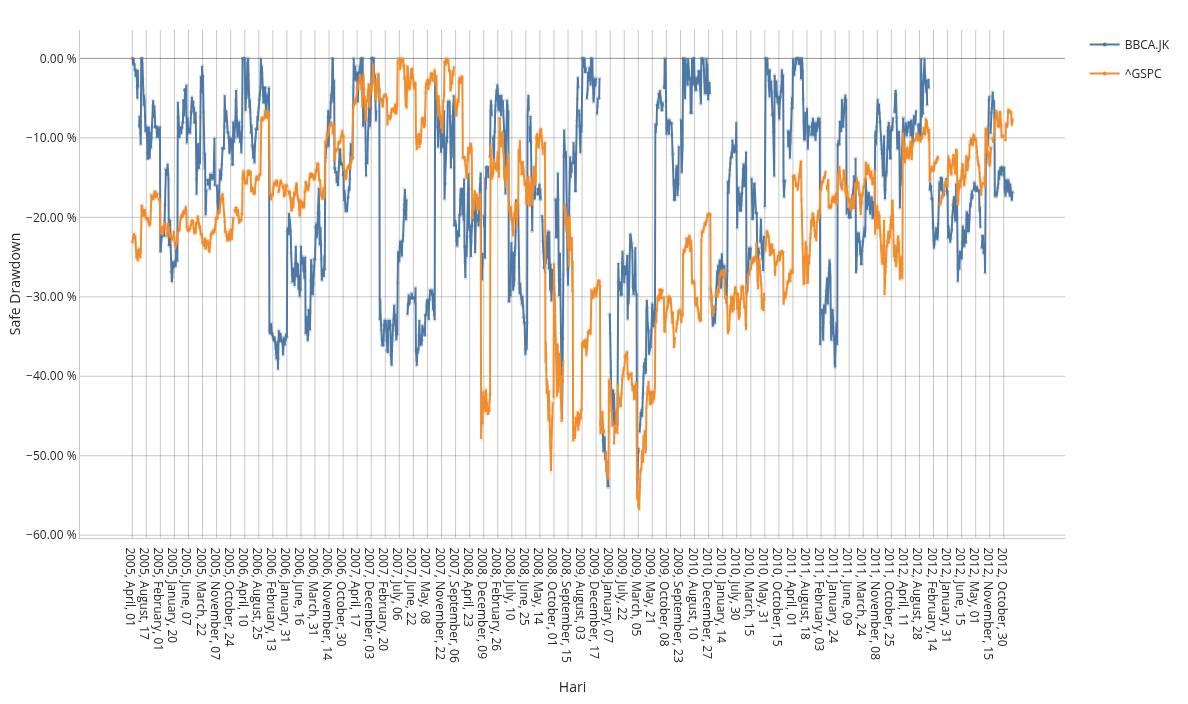

Pada grafik drawdown ini menunjukan S&P500 mengalami penurunan hingga -47% pada Desember 2008 dari ATH terakhir dan pada 2009 S&P500 dan BCA berada di sekitar -55%. BCA terlihat cukup berkorelasi dengan S&P500 tapi ada beberapa delay

In [20]:
session.link

http://localhost:39935